In [1]:
from selenium import webdriver
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.support.ui import Select

import pandas as pd
import pickle
import os
import sys
import warnings
import time

from bs4 import BeautifulSoup
import requests
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36", "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8", "Accept-Language": "en-US,en;q=0.9", "Referer": "https://www.ewg.org/tapwater/", "Connection": "keep-alive"}



from selenium.webdriver.edge.options import Options

edge_options = Options()
#edge_options.add_argument('--headless')
edge_options.add_argument("--disable-images")  # Disable images
edge_options.add_argument("--disable-javascript")  # Disable JavaScript
edge_options.add_argument("--disable-plugins")  # Disable plugins
edge_options.add_argument("--disable-extensions")  # Disable extensions
edge_options.add_argument("--blink-settings=imagesEnabled=false")  # Another image disabling flag


# Set a minimal User-Agent (like a text-only browser)
edge_options.add_argument("user-agent=Links (2.25; Linux 2.4.24)")

driver = webdriver.Edge(options=edge_options)
#driver.execute_cdp_cmd("Network.setBlockedURLs", {"urls": ["*.jpg", "*.png", "*.gif","*.svg"]})
#driver.execute_cdp_cmd("Network.enable", {})


driver.maximize_window()

driver.execute_script("document.body.style.zoom='67%'")

import warnings
warnings.filterwarnings('ignore')

There was an error managing msedgedriver (error sending request for url (https://msedgedriver.microsoft.com/LATEST_RELEASE_150_WINDOWS)); using driver found in the cache
Error sending stats to Plausible: error sending request for url (https://plausible.io/api/event)


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [ ]:
url="https://www.ratingraph.com/movies/"
driver.get(url)
time.sleep(5)

In [ ]:
if driver.find_element(By.CSS_SELECTOR, 'div[id="qc-cmp2-x"]'):
    box=driver.find_element(By.CSS_SELECTOR, 'div[id="qc-cmp2-x"]')
    button=box.find_element(By.CSS_SELECTOR, 'button[id="accept-x"]')
    driver.execute_script('arguments[0].click()', button)
    time.sleep(2)

In [4]:
toplist_button=driver.find_element(By.CSS_SELECTOR, 'select[name="x"]')
Select(toplist_button).select_by_value('250')
time.sleep(2)

In [ ]:
from selenium.common.exceptions import NoSuchElementException, StaleElementReferenceException

df = pd.DataFrame()
errors = 0

while True:
    try:
        next_button = driver.find_element(By.CSS_SELECTOR, 'a.x.next')

        classes = next_button.get_attribute('class')
        if 'disabled' in classes:
            print("Reached last page.")
            break

        driver.execute_script('arguments[0].click()', next_button)
        errors = 0

    except (NoSuchElementException, StaleElementReferenceException):
        errors += 1
        if errors >= 5:
            print("Next button not found after 5 tries, stopping.")
            break
        time.sleep(1)
        continue

    time.sleep(1)  # let the new page render before reading it

    html = driver.page_source
    table = pd.read_html(html)[-1]
    df = pd.concat([df, table], ignore_index=True)

    print((len(df) / 313500) * 100, end='\r')

In [ ]:
df.to_csv('imdb_ratings.csv', index=False)

In [101]:
df=pd.read_csv('imdb_ratings.csv')

In [102]:
df=df[['Title', 'Year', 'Genres', 'Total votes', 'Average rating']]

In [103]:
df

,Title,Year,Genres,Total votes,Average rating
0,The Shawshank Redemption,1994,Drama,3209672,9.3
1,The Dark Knight,2008,"Action, Drama, Crime, Thriller",3191343,9.1
2,Inception,2010,"Action, Adventure, Sci-fi, Thriller",2837439,8.8
3,Fight Club,1999,"Drama, Crime, Thriller",2631972,8.8
4,Forrest Gump,1994,"Romance, Drama",2511864,8.8
...,...,...,...,...,...
313275,Magnus Lindberg - den siste rockpoeten,2005,Biography,5,1.0
313276,Portaitissa of Donetsk,2018,"Documentary, Drama",5,1.0
313277,Hitler's Best Kept Secret: The Eva Braun Tapes,2020,Documentary,5,1.0
313278,When Is the War?!,2019,"Documentary, Biography",5,1.0


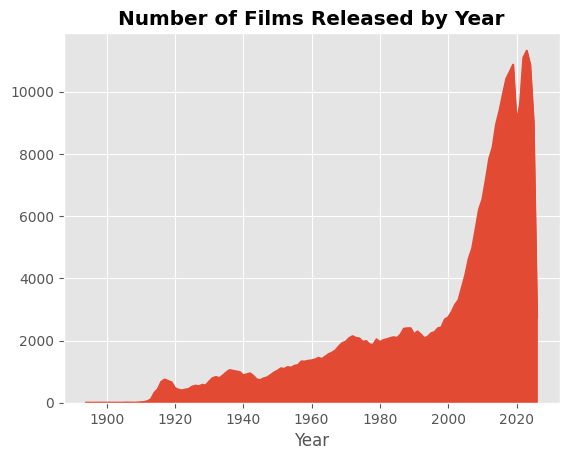

In [104]:
df.groupby('Year')['Title'].count().plot.area()
plt.title('Number of Films Released by Year', fontweight='bold')
plt.show()

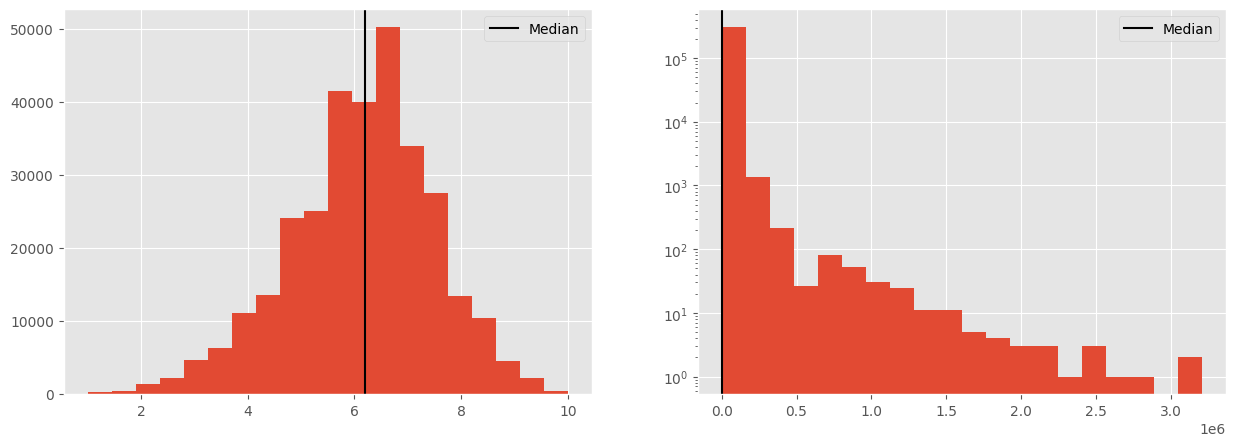

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

df['Average rating'].hist(ax=ax1, bins=20)
ax1.axvline(df['Average rating'].median(), c='Black', label='Median')
ax1.legend()

df['Total votes'].hist(ax=ax2, bins=20)
ax2.axvline(df['Total votes'].median(), c='Black', label='Median')
ax2.set_yscale('log')
ax2.legend()

In [107]:
df=df[df['Total votes']>=10000]

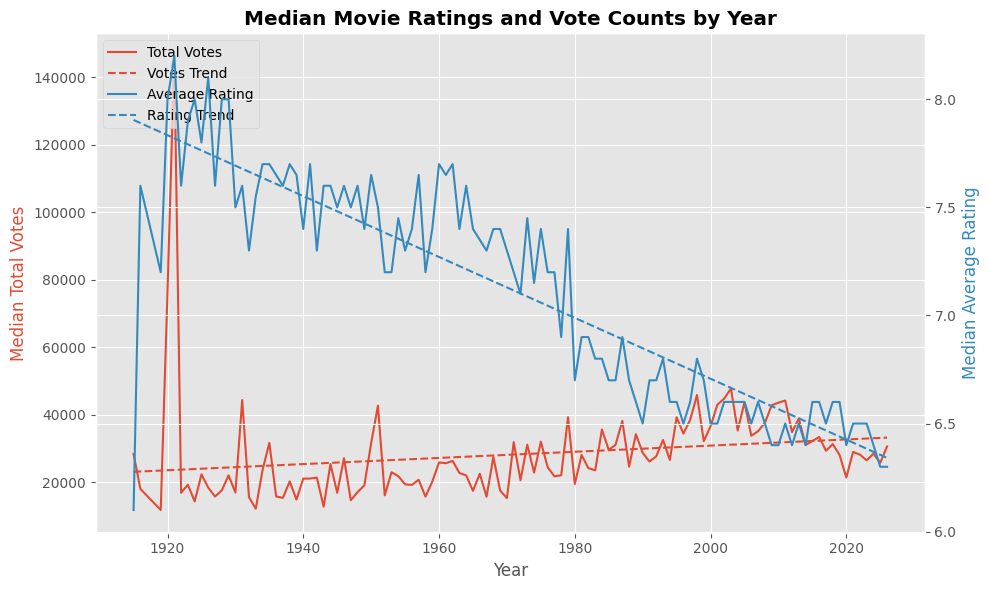

In [108]:
import numpy as np
import matplotlib.pyplot as plt

grouped = df.groupby('Year')[['Total votes', 'Average rating']].median()

fig, ax1 = plt.subplots(figsize=(10,6))
ax2 = ax1.twinx()

x = grouped.index.values

ax1.plot(x, grouped['Total votes'], color='C0', label='Total Votes', alpha=1)
z1 = np.polyfit(x, grouped['Total votes'], 1)
ax1.plot(x, np.poly1d(z1)(x), color='C0', linestyle='--', label='Votes Trend')
ax1.set_ylabel('Median Total Votes', color='C0')

ax2.plot(x, grouped['Average rating'], color='C1', label='Average Rating', alpha=1)
z2 = np.polyfit(x, grouped['Average rating'], 1)
ax2.plot(x, np.poly1d(z2)(x), color='C1', linestyle='--', label='Rating Trend')
ax2.set_ylabel('Median Average Rating', color='C1')

ax1.set_xlabel('Year')
plt.title('Median Movie Ratings and Vote Counts by Year', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [109]:
df['Genres'] = df['Genres'].apply(lambda x: x.split(','))
df_exploded = df.explode('Genres')

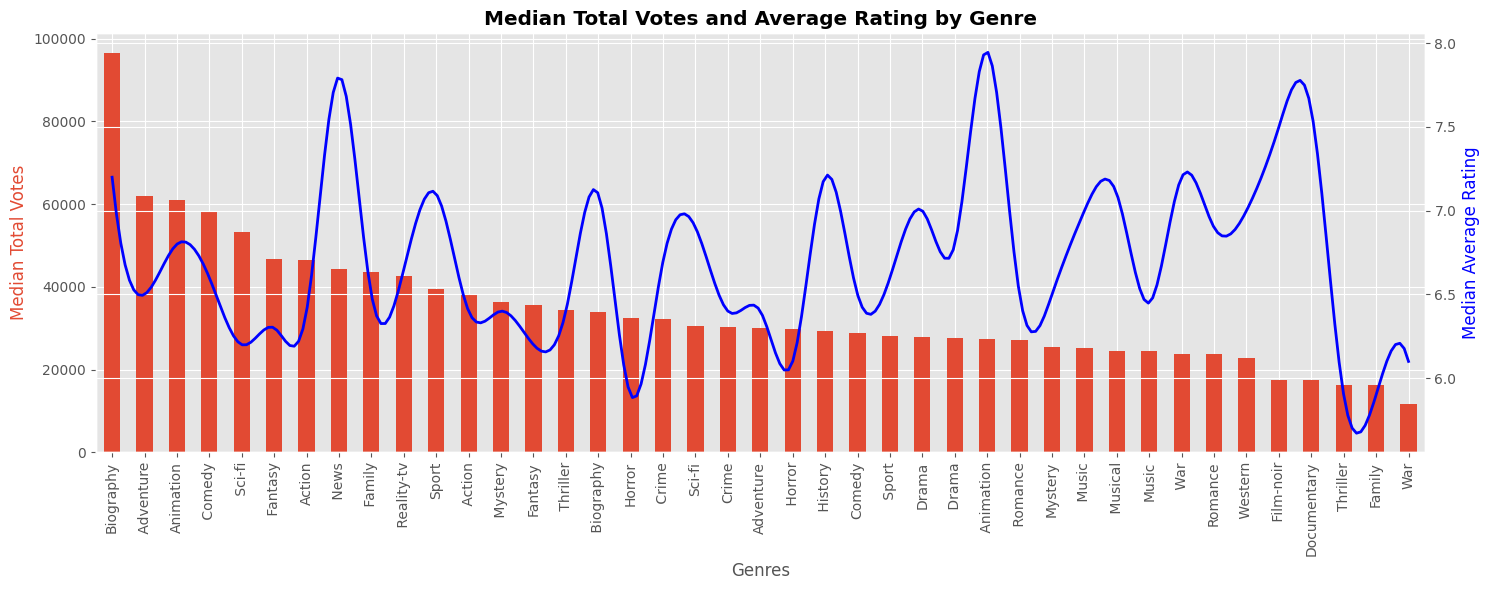

In [118]:
import numpy as np
from scipy.interpolate import make_interp_spline

grouped = (df_exploded.groupby('Genres')[['Total votes', 'Average rating']]
             .median()
             .sort_values('Total votes', ascending=False))

fig, ax = plt.subplots(figsize=(15,6))
ax2 = ax.twinx()

grouped.plot.bar(y='Total votes', ax=ax, color='C0', legend=False)
ax.set_ylabel('Median Total Votes', color='C0')

x = np.arange(len(grouped))
y = grouped['Average rating'].values

x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3)
y_smooth = spline(x_smooth)

ax2.plot(x_smooth, y_smooth, color='blue', linewidth=2)
ax2.set_ylabel('Median Average Rating', color='blue')

ax.set_title('Median Total Votes and Average Rating by Genre', fontweight='bold')
plt.tight_layout()
plt.show()

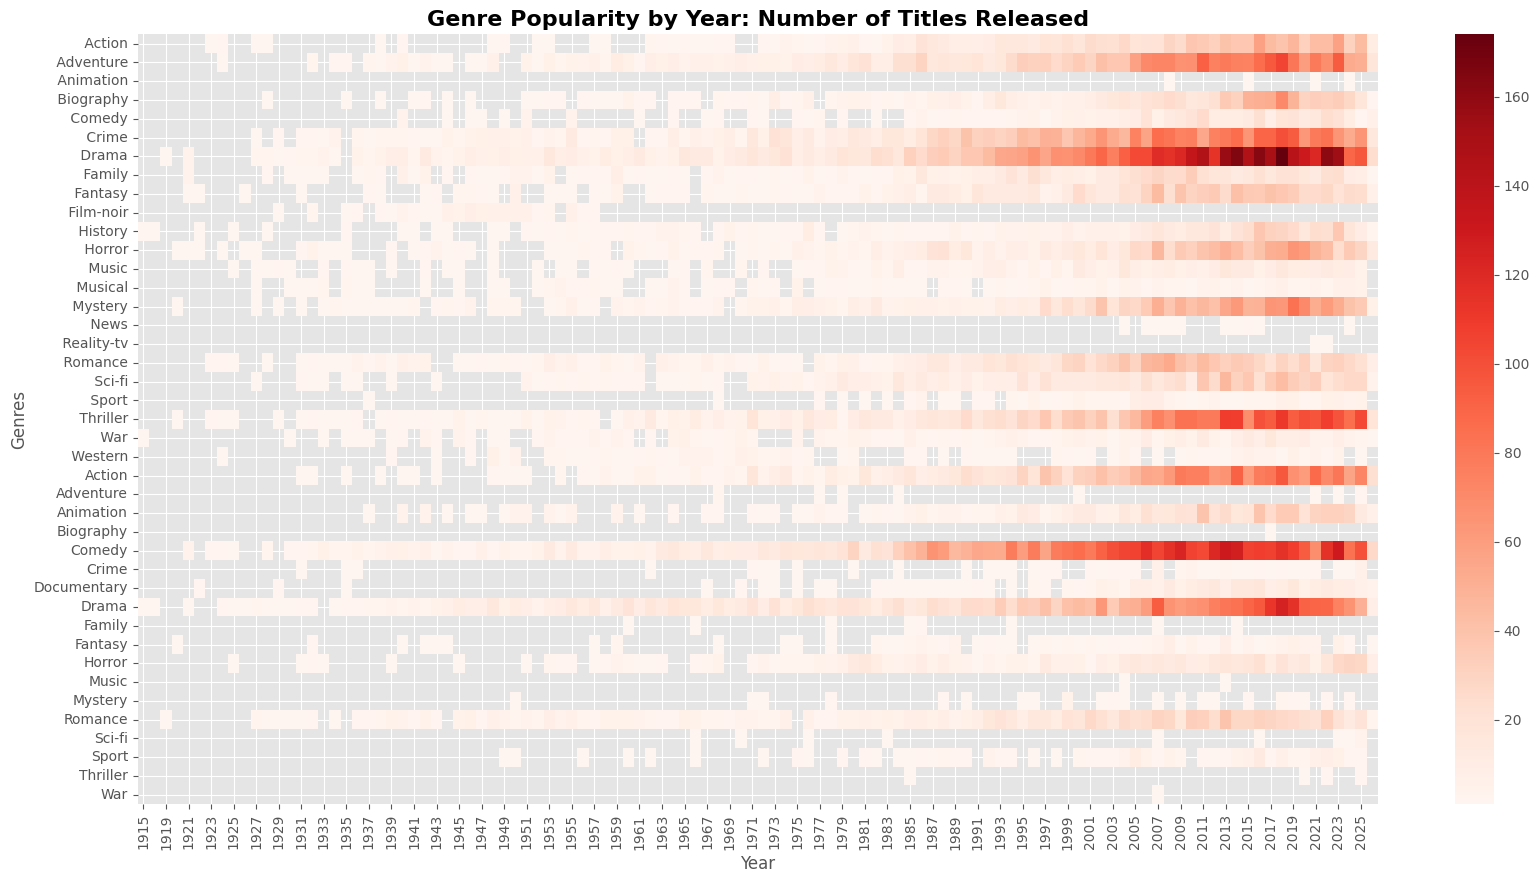

In [133]:
matrix=df_exploded.groupby(['Year', 'Genres'])['Title'].count().reset_index().pivot(index='Genres', columns='Year', values='Title')

plt.figure(figsize=(20,10))
sns.heatmap(matrix, cmap='Reds')
plt.title('Genre Popularity by Year: Number of Titles Released', fontsize=16, fontweight='bold')
plt.show()